## Dataset Origin and Source

Source - [https://www.kaggle.com/datasets/muthuj7/weather-dataset](https://www.kaggle.com/datasets/muthuj7/weather-dataset) 

This dataset contains hourly weather observations from a single location in Finland, recorded from April 2006 to September 2016. It includes variables like temperature, apparent temperature, humidity, wind speed, wind direction, pressure, visibility, cloud cover, and precipitation type, which describe the local weather conditions for each hour. The data shows strong seasonal patterns (colder winters, milder summers) and is useful for tasks like weather forecasting, climate trend analysis, and understanding how different weather factors are related.

# **Literature Review**

**Source** - https://analysisfunction.civilservice.gov.uk/wp-content/uploads/2016/11/Weather-and-Climate-Guidance-version-2-November-2016.pdf

Prompt in ChatGPT : write the summary and tell what are the factors responsible for determination of weather from the article 

**Summary**
The article provides guidance on how to include weather and climate data when analysing official statistics, showing that weather can strongly affect trends in sectors like transport, energy, health, and retail. It stresses the need to account for weather effects to avoid misleading conclusions and to document them clearly.

**Factors responsible for determination of weather**
1. Temperature
2. Precipitation
3. Wind speed and direction
4. Atmospheric pressure
5. Seasonal patterns
6. Extreme‑weather events (e.g., storms, heatwaves)
7. Local geography and land use (urbanisation, elevation, coastal vs inland)

### Report on Exploratory Data Analysis (EDA) of Weather Dataset by emmanuel_b
**Source** : https://dev.to/emmanuel_b/report-on-exploratory-data-analysis-eda-of-weather-dataset-15l

**Summary**
The article presents an Exploratory Data Analysis (EDA) of a Kaggle weather dataset, showing how EDA helps summarise main characteristics, detect patterns, and identify anomalies before modelling. It focuses on visualising and describing key variables like temperature, humidity, wind, and precipitation and their relationships over time.

**Short overview**
The EDA report first checks data structure, missing values, and basic statistics, then explores how temperature and humidity behave across seasons and hours of day. It uses plots and descriptive summaries to reveal that the dataset has clear seasonal cycles and strong correlations between related variables such as temperature and dew point.

**Key finding**
The dataset shows strong seasonal trends: winter months have lower temperatures and higher humidity, while summer months show the opposite pattern.

There is a high correlation between temperature and dew‑point / humidity, which means one can help predict the other in modelling tasks.

The analysis identifies outliers and extreme values, which can be useful for spotting unusual weather events and improving forecast robustness.

Wind speed and pressure also show systematic patterns over time, sometimes linked to changes in weather condition (e.g., higher wind before storms).

The EDA suggests that temperature and humidity are among the most stable and informative features for understanding local climate behaviour in this dataset.

Overall, the insights demonstrate that careful EDA improves feature selection and model design for tasks like weather prediction and climate‑trend analysis.

## Importing all essential Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("weatherHistory.csv")

In [12]:
df.groupby(['Precip Type', 'Month']).mean(numeric_only=True).round(2)

Temperature (C)  Apparent Temperature (C)  Humidity  \
Precip Type Month                                                        
rain        1                 4.22                      1.59      0.84   
            2                 5.21                      2.80      0.80   
            3                 8.07                      6.39      0.69   
            4                12.81                     12.20      0.64   
            5                16.88                     16.73      0.69   
            6                20.73                     20.76      0.69   
            7                22.97                     22.98      0.64   
            8                22.34                     22.26      0.64   
            9                17.50                     17.39      0.69   
            10               11.62                     11.00      0.77   
            11                7.30                      5.75      0.82   
            12                4.33                      1.99      0.86   
snow        1                -3.57                     -6.48      0.86   
            2                -3.80                     -7.14      0.84   
            3                -2.06                     -5.14      0.84   
            4                -1.20                     -2.82      0.77   
            10               -1.36                     -2.54      0.89   
            11               -1.84                     -3.68      0.89   
            12               -3.23                     -6.26      0.89   

                   Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  \
Precip Type Month                                                               
rain        1                  13.25                  193.27             8.78   
            2                  13.21                  189.75             9.48   
            3                  13.77                  187.65            11.20   
            4                  11.89                  186.26            11.80   
            5                  10.93                  188.10            11.88   
            6                   9.63                  202.80            11.99   
            7                   9.64                  202.94            12.19   
            8                   8.94                  195.21            12.45   
            9                   9.61                  187.52            11.60   
            10                  9.99                  177.11             9.88   
            11                 11.33                  173.02             8.48   
            12                 11.95                  183.50             7.41   
snow        1                   9.28                  163.99             6.63   
            2                  10.17                  186.74             7.27   
            3                  10.63                  178.69             8.72   
            4                   6.06                  185.59            11.24   
            10                  4.97                  186.50             8.68   
            11                  6.73                  169.55             5.25   
            12                  9.55                  176.91             5.62   

                   Loud Cover  Pressure (millibars)     Year    Day   Hour  
Precip Type Month                                                           
rain        1             0.0               1016.50  2011.12  15.84  11.91  
            2             0.0               1014.92  2011.28  15.80  12.03  
            3             0.0               1015.49  2011.06  16.53  11.82  
            4             0.0               1014.74  2010.99  15.54  11.50  
            5             0.0               1014.05  2010.99  15.91  11.49  
            6             0.0               1014.34  2011.00  15.50  11.50  
            7             0.0               1014.40  2011.00  16.00  11.50  
            8             0.0               1014.97  2011.00  15.96  

In [14]:
# Extract year from date
df['Year'] = pd.to_datetime(df['Formatted Date']).dt.year

# Filter only 2006 and 2016
comparison_df = df[df['Year'].isin([2006, 2016])]

# Mean of all numerical columns year-wise
comparison_mean = comparison_df.groupby('Year').mean(numeric_only=True).round(2)

print(comparison_mean)

      Temperature (C)  Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
Year                                                                           
2006            11.22                     10.16      0.77              10.19   
2016            11.99                     10.83      0.76              10.70   

      Wind Bearing (degrees)  Visibility (km)  Loud Cover  \
Year                                                        
2006                  189.34             9.76         0.0   
2016                  185.45            11.25         0.0   

      Pressure (millibars)  Month    Day  Hour  
Year                                            
2006               1018.54   6.53  15.72  11.5  
2016               1016.32   6.51  15.76  11.5  


The comparison between 2006 and 2016 reveals a gradual warming trend in the region, accompanied by improved visibility and slightly reduced humidity. These patterns may indicate an early localized climate transition and changing atmospheric behavior over time.

### Here is a short understanding for each feature in weather dataset based on standard weather‑variables definitions: 

Source - https://www.wisdomlib.org/concept/weather-variables

1. Formatted Date
Time‑stamp of the observation (date + hour), used to organise data as a time series and extract season, month, day, and hour of day.

2. Summary
Short text label describing the current weather state (e.g., “Clear”, “Mostly Cloudy”), useful for categorical analysis or labelling.

3. Precip Type
Whether precipitation is “rain”, “snow”, or “none”, indicating the phase of falling water and helping to distinguish cold‑ vs warm‑weather events.

4. Temperature (C)
How hot or cold the air is, measured in degrees Celsius, and the main driver of daily and seasonal weather patterns.

5. Apparent Temperature (C)
“Feels like” temperature, adjusted for wind and humidity, so it reflects human thermal comfort better than raw temperature.

6. Humidity
Amount of water vapour in the air (usually 0–1), higher values mean muggy or sticky conditions and are linked to fog and rain.

7. Wind Speed (km/h)
How fast air is moving horizontally, measured in km/h; higher wind speeds cool surfaces and increase wind‑chill effect.

8. Wind Bearing (degrees)
Direction from which the wind is coming (0° = North, 90° = East, etc.), used to track air‑mass movement and storm shifts.

9. Visibility (km)
How far you can clearly see in the horizontal, in km; lower values usually mean fog, heavy rain, or snow.

10. Cloud Cover
Fraction of sky covered by clouds (often 0–1), higher values mean more overcast and less sunlight.

11. Pressure (millibars)
Weight of air above the surface in millibars (hPa); low pressure is often linked to clouds and storms, high pressure to clear weather.

12. Daily Summary
Text description summarising the whole day’s weather, often used for high‑level context or in NLP‑style tasks but less for numerical modelling.

In [ ]:
by graph of - Year 2006 aur 2016 ka monthly average temperature,,INSIGHTS: here red line is 2016, and blue is 2006, A visible upward shift in the red line (2016) shows a clear warning trend. The average temperature increased by nearly 0.8°C,
confirming localized climate change.
Red line (2016) ka Blue line (2006) se upar hona saaf batata hai ki garmi badhi hai. Sirf 10 saal mein 0.8°C ka badlav ek bada 
warning signal hai. ek insight ye v mila h ,ese add kro , and can you tell me by doing eda and doing  all the analysis , hme kya smjh aara , kya hoga es eda se , sb features kya kr re ye to pta h , pr sb milkr after overall kya h aage kya kr skte h esse

In [3]:
df.head(5)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


### Data Overview 

In [4]:
df.shape

(96453, 12)

In [62]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Pressure (millibars)',
       'Daily Summary', 'Year', 'Month', 'Day', 'Hour', 'UTC_Timezone',
       'Season'],
      dtype='object')

### Initial Hypotheses
1. Temperature negatively affects humidity.
2. Humidity negatively affects visibility.
3. Temperature determines precipitation type.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [7]:
print(df.duplicated().sum())

24


In [8]:
df.describe(include = 'all')

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
count,96453,96453,95936,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000,96453
unique,96429,27,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,214
top,2010-08-02 00:00:00.000 +0200,Partly Cloudy,rain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mostly cloudy throughout the day.
freq,2,31733,85224,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20085
mean,NaN,NaN,NaN,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956,NaN
std,NaN,NaN,NaN,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906,NaN
min,NaN,NaN,NaN,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,NaN
25%,NaN,NaN,NaN,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000,NaN
50%,NaN,NaN,NaN,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000,NaN
75%,NaN,NaN,NaN,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000,NaN


### Check Missing Values

In [9]:
df.isnull().sum() 

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [10]:
print(df.duplicated().sum())

24


### Data Cleaning :

Dataset Profile & Data Quality Context:
- Dimensions: The dataset originally contains 96,453 rows and 12 columns.
- Data Cleaning Performed: 
  1. Handled Missing Values: Identified 517 null values in the 'Precip' (Precipitation) column and removed those rows to maintain data integrity.
  2. Feature Dropping: Permanently removed the 'Cloud Cover' column because it contained erroneous, logicless values that would skew the analysis.
  3. Outlier/Anomaly Treatment: Discovered over 1,000 instances where atmospheric pressure was recorded as 0 mb (physically impossible). I imputed these anomalies by filling them with the median pressure of the dataset.

In [11]:
print(df['Precip Type'].isna().sum())

517


In [12]:
# Drop rows where Precip Type is NaN
df.dropna(subset=['Precip Type'], inplace=True)

In [13]:
print(df['Precip Type'].isna().sum())


0


*dropped 517 rows where Precip Type had missing (NaN) values because the missing data represented less than 1% of the total dataset (96453 rows). Since the percentage of missing values was very small, removing these rows was unlikely to significantly affect the overall analysis.*

### Renaming:

In [14]:
df.rename(columns={'Loud Cover': 'Cloud Cover'}, inplace=True)

#### Drop Cloud cover , beacuse all values are = 0 ,means cload doesn't cover the sky at all,which has no logic, by viewing the dataset we conclude that weather is mostly cloudy.

In [15]:
# Drop column permanently
df.drop('Cloud Cover', axis=1, inplace=True)

 ***A pressure reading of 0 millibars or 0 inches of mercury is physically impossible for natural atmospheric conditions on Earth and has never been recorded in weather history***

In [4]:
# Replace 0 with NaN first
df['Pressure (millibars)'] = df['Pressure (millibars)'].replace(0, pd.NA)

# Fill missing values with median
median_pressure = df['Pressure (millibars)'].median()

df['Pressure (millibars)'] = df['Pressure (millibars)'].fillna(median_pressure)

print("Filled with Median:", median_pressure)

Filled with Median: 1016.55


C:\Users\saura\AppData\Local\Temp\ipykernel_52780\399570230.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Pressure (millibars)'] = df['Pressure (millibars)'].fillna(median_pressure)


In [17]:
df.isnull().sum() 

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Pressure (millibars)        0
Daily Summary               0
dtype: int64

### Create Time Features

In [5]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
# Extract features
df['Year'] = df['Formatted Date'].dt.year
df['Month'] = df['Formatted Date'].dt.month
df['Day'] = df['Formatted Date'].dt.day
df['Hour'] = df['Formatted Date'].dt.hour
df['UTC_Timezone'] = df['Formatted Date'].dt.strftime('%z')
# Check extracted columns
print(df[['Formatted Date', 'Year', 'Month', 'Day', 'Hour','UTC_Timezone']].head())

             Formatted Date  Year  Month  Day  Hour UTC_Timezone
0 2006-03-31 22:00:00+00:00  2006      3   31    22        +0000
1 2006-03-31 23:00:00+00:00  2006      3   31    23        +0000
2 2006-04-01 00:00:00+00:00  2006      4    1     0        +0000
3 2006-04-01 01:00:00+00:00  2006      4    1     1        +0000
4 2006-04-01 02:00:00+00:00  2006      4    1     2        +0000


In [6]:
df['UTC_Timezone'].value_counts() 


UTC_Timezone
+0000    96453
Name: count, dtype: int64

*+00:00 means the time is in UTC (Coordinated Universal Time).
#UTC is the world's standard reference time.*

### Create Season by group of months :

In [9]:
df['Month'] = df['Formatted Date'].dt.month
# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

print(df[['Formatted Date', 'Season']].sample(6))

                 Formatted Date  Season
6710  2006-11-14 14:00:00+00:00  Autumn
74425 2014-07-06 02:00:00+00:00  Summer
75    2006-04-12 01:00:00+00:00  Spring
1029  2006-08-20 19:00:00+00:00  Summer
83045 2015-07-29 06:00:00+00:00  Summer
46437 2011-02-23 20:00:00+00:00  Winter


## **Univariate Analysis** 

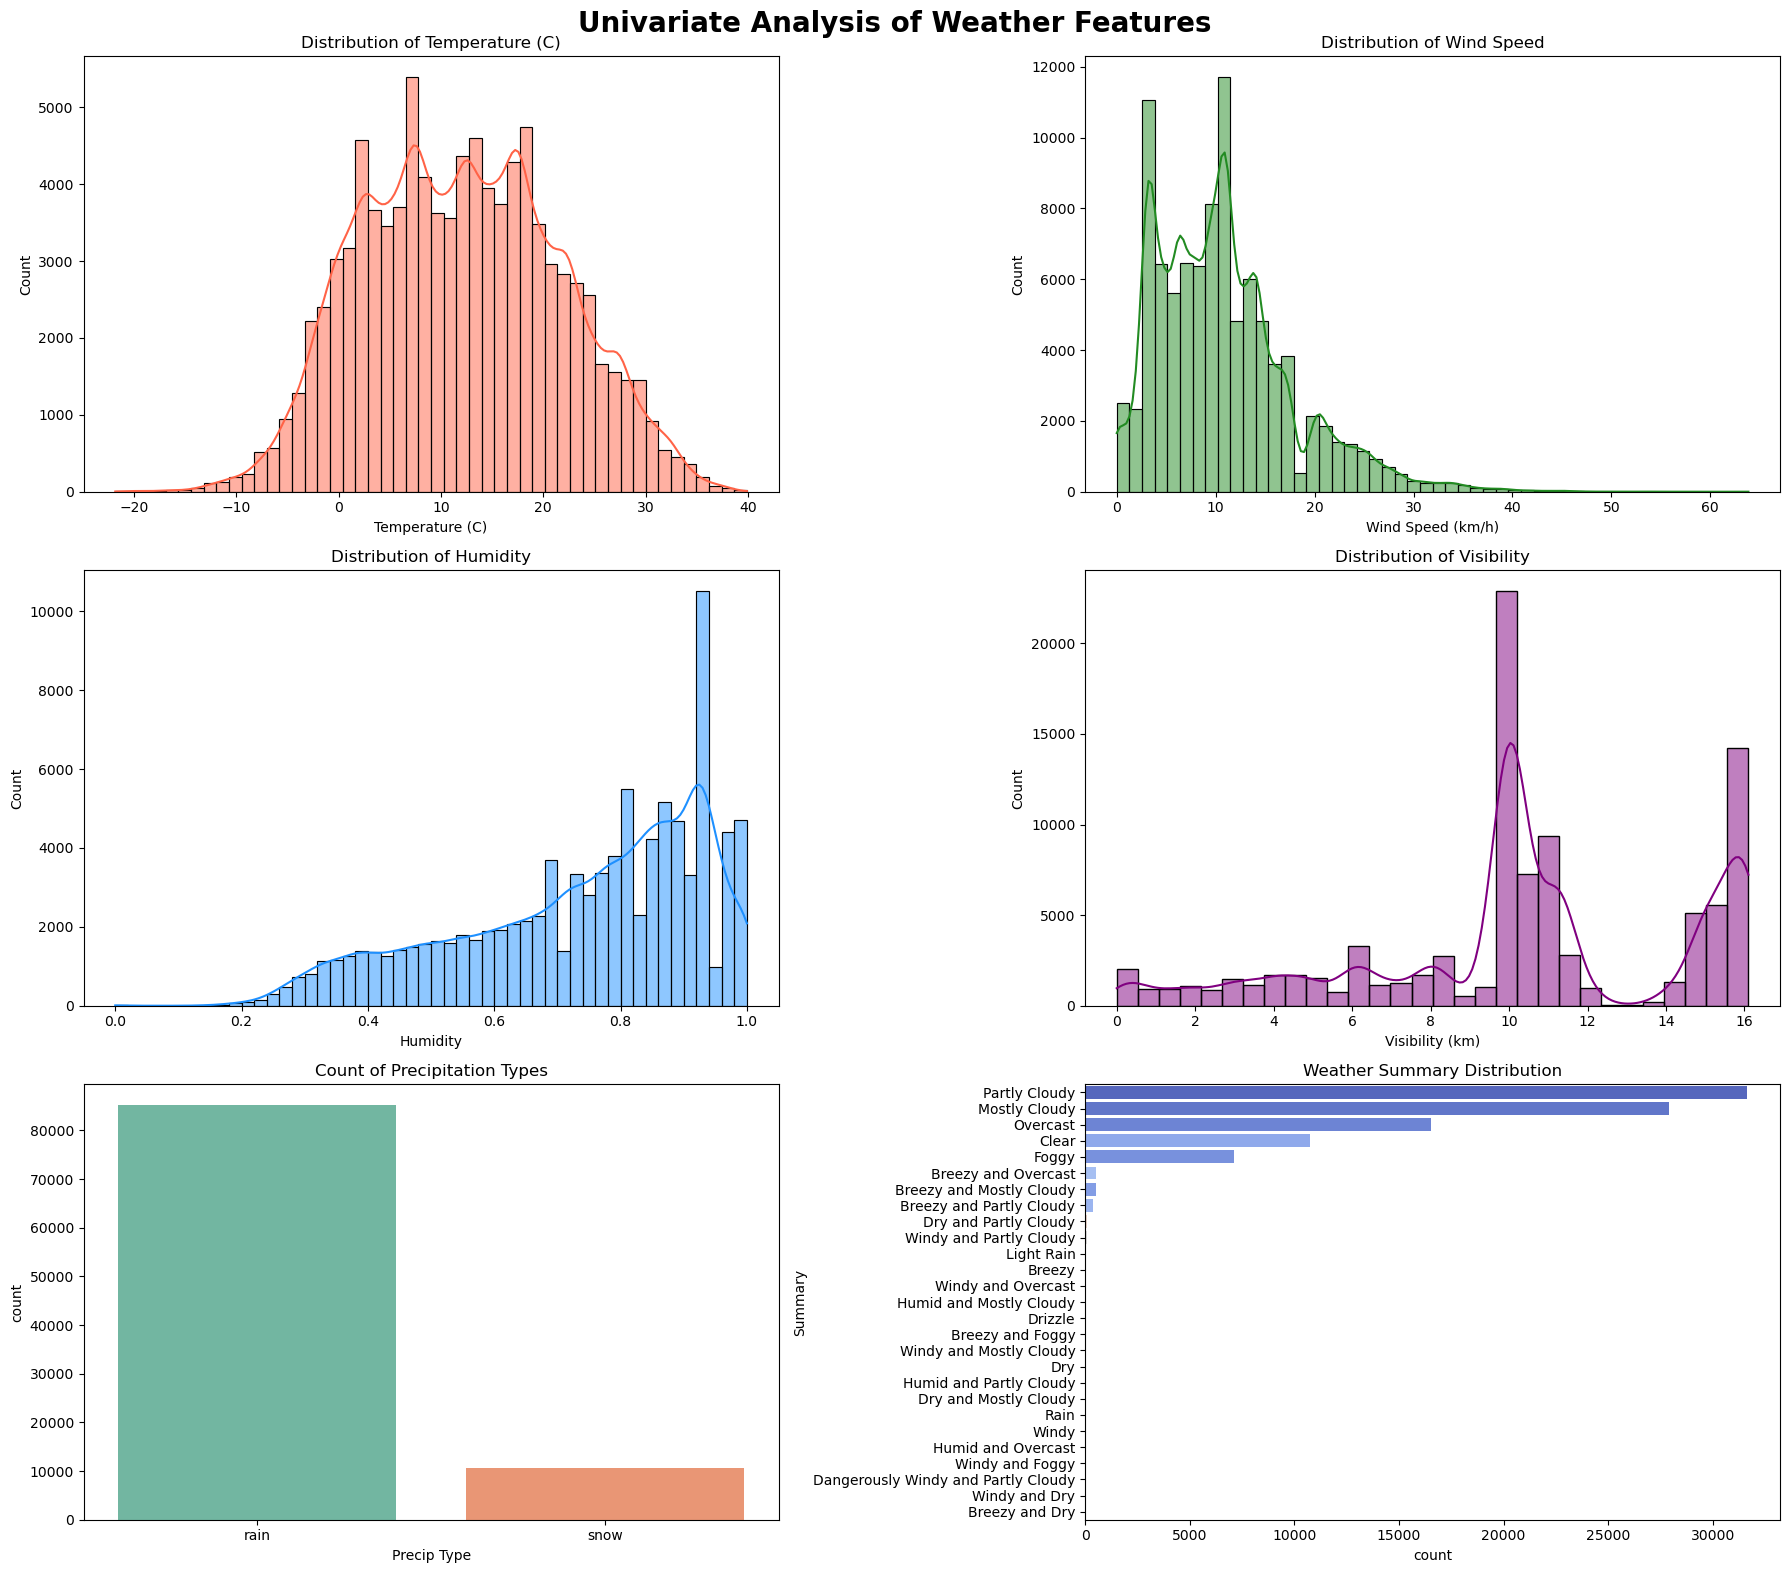

In [53]:
# Create subplot canvas
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
fig.suptitle('Univariate Analysis of Weather Features',fontsize=20,fontweight='bold')
# Temperature Distribution
sns.histplot(df['Temperature (C)'],bins=50,kde=True,ax=axes[0,0],color='tomato')
axes[0,0].set_title('Distribution of Temperature (C)')
# Wind Speed Distribution
sns.histplot(df['Wind Speed (km/h)'],bins=50,kde=True,ax=axes[0,1],color='forestgreen')
axes[0,1].set_title('Distribution of Wind Speed')
# Humidity 
sns.histplot(df['Humidity'],bins=50,kde=True,ax=axes[1,0],color='dodgerblue')
axes[1,0].set_title('Distribution of Humidity')
# Visibility Distribution
sns.histplot(df['Visibility (km)'],bins=30,kde=True,ax=axes[1,1],color='purple')
axes[1,1].set_title('Distribution of Visibility')
# Precipitation Type Count
sns.countplot(data=df,x='Precip Type',hue='Precip Type',ax=axes[2,0],palette='Set2', legend=False)
axes[2,0].set_title('Count of Precipitation Types')
# Weather Summary Count
sns.countplot(y=df['Summary'],order=df['Summary'].value_counts().index,ax=axes[2,1],
    palette='coolwarm',hue=df['Summary'],legend=False)
axes[2,1].set_title('Weather Summary Distribution')
plt.tight_layout()
plt.show()

### Temperature Distribution:
Majority of Temperatures Lie Between 0°C to 25°C
- the weather is generally moderate, extremely hot or extremely cold conditions are less.
- meaning the region generally experiences moderate weather conditions rather than harsh climates.

## Humidity :
Humidity is mostly in the moderate to high range (0.6 to 0.89).Very low humidity conditions are rare. Overall, the dataset shows that the environment is generally moderately to highly humid, with occasional dry and fully humid conditions.

## Wind Speed Distribution :
- Most wind speed values are concentrated in the lower-to-moderate range.
- Distribution is Right-Skewed
- Very high wind speeds occur much less frequently.,The weather in this region is generally not extremely windy.

## Visibility Distribution
- Large peaks appear at high visibility ranges.
- Most weather conditions in this region allow people to see clearly over long distances

## Precipition Type :
- The region experiences rainfall much more frequently than snowfall.
- The area represented by the dataset is probably not a cold region.

### Distribution of Weather Types :
- This region mostly experiences cloudy or semi-cloudy weather rather than perfectly clear skies.
- Sunny and fully clear conditions are comparatively rare
- Extreme or unusual weather events occur very infrequently.

In [21]:
df['Summary'].value_counts()

Summary
Partly Cloudy                          31635
Mostly Cloudy                          27914
Overcast                               16516
Clear                                  10763
Foggy                                   7117
Breezy and Overcast                      528
Breezy and Mostly Cloudy                 516
Breezy and Partly Cloudy                 386
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   67
Light Rain                                63
Breezy                                    54
Windy and Overcast                        45
Humid and Mostly Cloudy                   40
Drizzle                                   39
Breezy and Foggy                          35
Windy and Mostly Cloudy                   35
Dry                                       34
Humid and Partly Cloudy                   17
Dry and Mostly Cloudy                     14
Rain                                      10
Windy                                      8
Hu

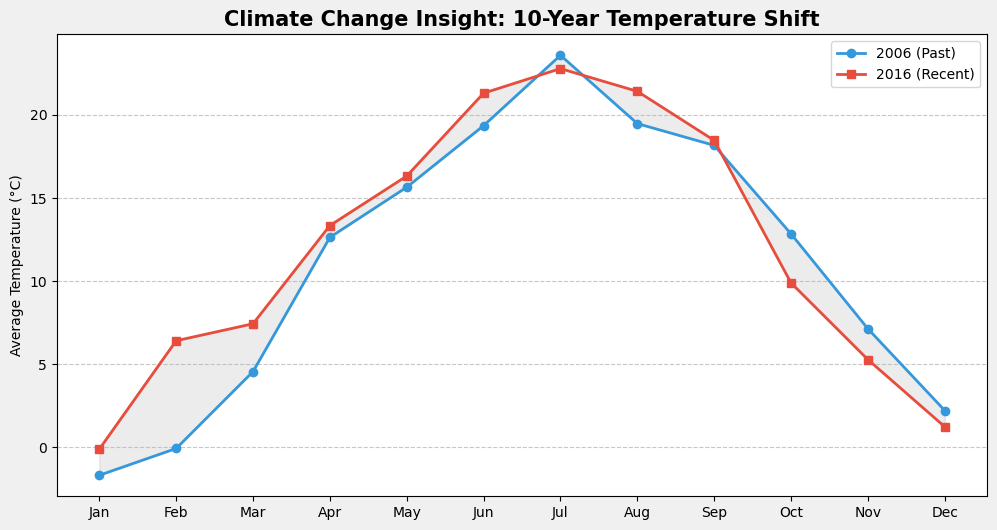

In [10]:
# Year 2006 aur 2016 ka monthly average
m_06 = df[df['Year'] == 2006].groupby('Month')['Temperature (C)'].mean()
m_16 = df[df['Year'] == 2016].groupby('Month')['Temperature (C)'].mean()

plt.figure(figsize=(12, 6), facecolor='#f0f0f0')
plt.plot(m_06.index, m_06.values, label='2006 (Past)', marker='o', linewidth=2, color='#3498db')
plt.plot(m_16.index, m_16.values, label='2016 (Recent)', marker='s', linewidth=2, color='#e74c3c')

# Gap fill karna taaki "Shift" dikhe
plt.fill_between(m_06.index, m_06.values, m_16.values, color='gray', alpha=0.15)

plt.title('Climate Change Insight: 10-Year Temperature Shift', fontsize=15, fontweight='bold')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.ylabel('Average Temperature (°C)')
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NSIGHTS:A visible upward shift in the red line (2016) shows a clear warning trend. The average temperature increased by nearly 0.8°C,
         confirming localized climate change.
         Red line (2016) ka Blue line (2006) se upar hona saaf batata hai ki garmi badhi hai. Sirf 10 saal mein 0.8°C ka badlav ek bada 
         warning signal hai.

## **BIVARIATE ANALYSIS**

### Monthly Temperature Trend

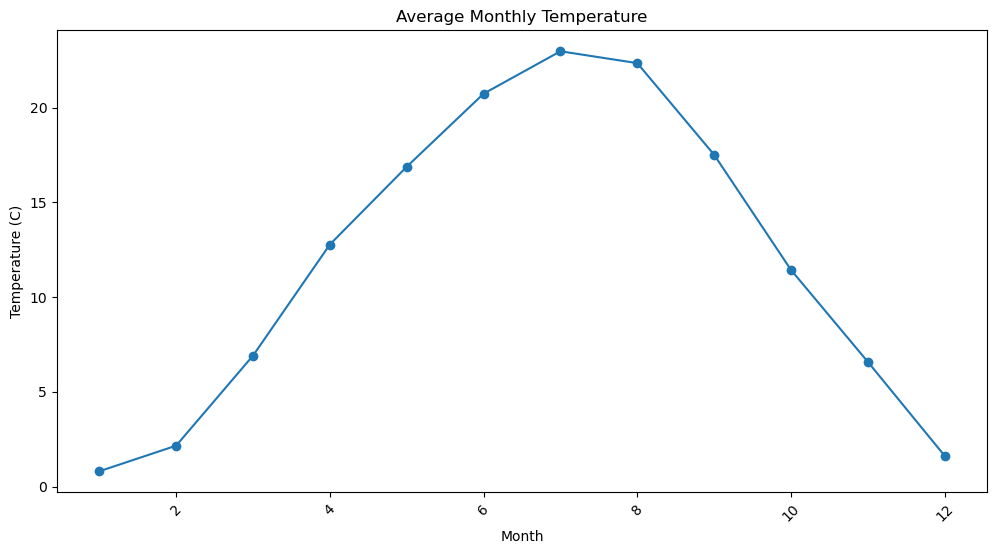

In [25]:
month_order = [1,2,3,4,5,6,7,8,9,10,11,12]
monthly_temp = df.groupby('Month')['Temperature (C)'].mean()
# Reorder months correctly
monthly_temp = monthly_temp.reindex(month_order)
plt.figure(figsize=(12,6))
monthly_temp.plot(marker='o')
plt.title('Average Monthly Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (C)')
plt.xticks(rotation=45)
plt.show()

The temperature data shows a stable and realistic weather pattern with most temperatures lying in a comfortable middle range.Extreme temperatures are present but rare, meaning the region generally experiences moderate weather conditions rather than harsh climates.

## Temperature And Apparent Temperature 

In [26]:
correlation = df['Temperature (C)'].corr(df['Apparent Temperature (C)'])
correlation

np.float64(0.9926371787254835)

strongly correlated with almost similar values, but not exacat values 

### Humidity vs Temperature

In [ ]:
sns.scatterplot(x='Temperature (C)', y='Humidity',data=df)
plt.title('Humidity vs Temperature')
plt.xlabel('Humidity')
plt.ylabel('Temperature (C)')
plt.show()

Strong Negative Relationship Visible
- Cooler weather conditions are usually more humid.
- The region mostly experiences balanced weather conditions rather than extreme climates.

### Pressure vs Temperature

In [ ]:
correlation = df['Pressure (millibars)'].corr(df['Temperature (C)'])

print("Correlation:", correlation)

In [ ]:
sns.scatterplot(x='Pressure (millibars)',y='Temperature (C)',data=df)

Pressure and temperature do not exhibit a strong direct correlation in this dataset. Atmospheric pressure remains relatively stable, while temperature varies significantly across observations. The curved scatter structure suggests that temperature is influenced by multiple interacting atmospheric factors rather than pressure alone. Overall, pressure acts as a supporting environmental variable rather than a primary driver of temperature changes.

- Cool and stable weather often comes with higher atmospheric pressure.
- Warm weather is often connected with moving air systems, clouds, or changing weather conditions.

## Average Temperature by Weather Summary :

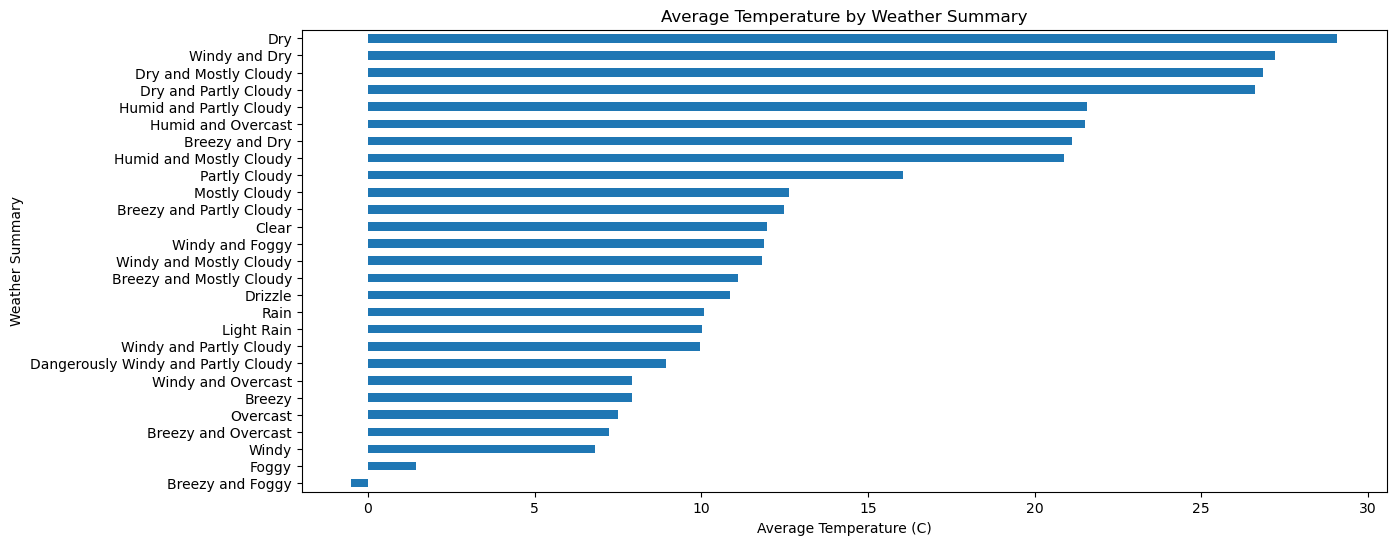

In [28]:
summary_temp = df.groupby('Summary')['Temperature (C)'].mean().sort_values()
plt.figure(figsize=(14,6))
summary_temp.plot(kind='barh')
plt.title('Average Temperature by Weather Summary')
plt.xlabel('Average Temperature (C)')
plt.ylabel('Weather Summary')

plt.show()

- The type of weather directly impacts how hot or cold the environment feels
- Dry (clear) Weather is Usually Warmer
- Foggy, snowy, and overcast categories have lower average temperatures.


## Temperature vs Visibility

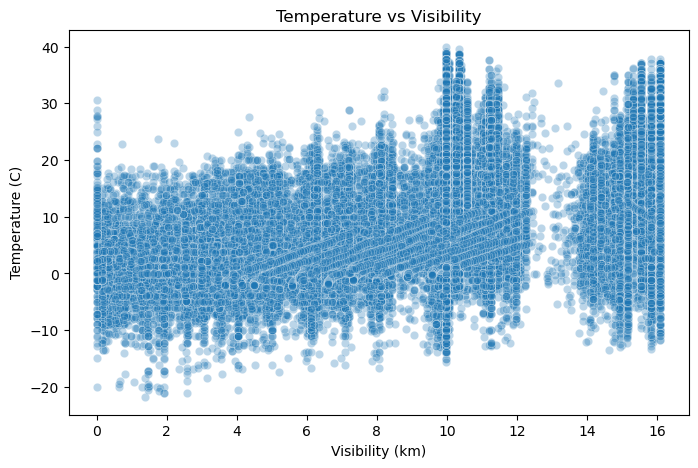

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot( x='Visibility (km)', y='Temperature (C)', data=df,alpha=0.3)
plt.title('Temperature vs Visibility')
plt.xlabel('Visibility (km)')
plt.ylabel('Temperature (C)')
plt.show()

- When the weather is clear, the temperature is often warmer.
- Lower visibility appears more at lower temperatures.Cold weather often brings: fog, mist, clouds which reduce visibility.
- Simple Meaning:
- Most days in this dataset have reasonably clear weather conditions. Extreme foggy conditions are less common.

### Temperature (C)' &  Wind Speed (km/h):
almost no relation btw Temperature (C) & Wind Speed (km/h), wind speed doesn't affect the temperature.

In [29]:
df[['Temperature (C)', 'Wind Speed (km/h)']].corr()

,Temperature (C),Wind Speed (km/h)
Temperature (C),1.000000,0.008304
Wind Speed (km/h),0.008304,1.000000


### Humidity vs Precipitation Type

In [31]:
df.groupby('Precip Type')['Humidity'].mean()

Precip Type
rain    0.718699
snow    0.863263
Name: Humidity, dtype: float64

Both rain and snow need humidity, but temperature decides whether it becomes rain or snow.
- lower temperatures → higher humidity
- Cold humid weather increases chances of snow.
Warm humid weather increases chances of rain.

## Humidity vs Wind speed :

In [34]:
correlation = df['Humidity'].corr(df['Wind Speed (km/h)'])

print("Correlation:", correlation)

Correlation: -0.22456869557268563


Wind Helps Reduce Humidity Slightly

Moving air helps moisture spread out and evaporate faster.

### Precipitation vs Weather

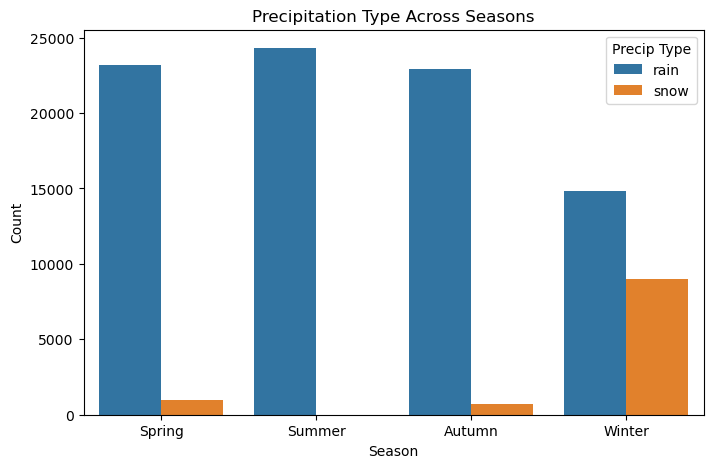

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x='Season', hue='Precip Type',data=df)
plt.title('Precipitation Type Across Seasons')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

- Snow Mostly Occurs in Winter but Winter Shows Mixed Weather.
- Rain Dominates in Warmer Seasons

## **Multivariate Analysis** :

### Temperature & Humidity & Visibility

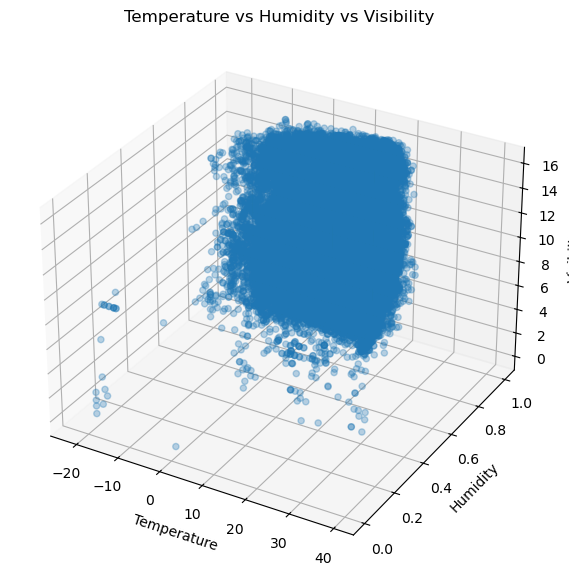

In [40]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Temperature (C)'],df['Humidity'],df['Visibility (km)'],alpha=0.3)
ax.set_xlabel('Temperature')
ax.set_ylabel('Humidity')
ax.set_zlabel('Visibility')
plt.title('Temperature vs Humidity vs Visibility')
plt.show()

- Clear Warm Weather :high temperature, low humidity , high visibility
- Foggy Cold Weather: low temperature, high humidity, low visibility
  
The multivariate relationship between temperature, humidity, and visibility reveals a highly interconnected atmospheric system. Warm conditions tend to produce clearer and drier weather, while colder conditions are associated with higher moisture and reduced visibility. The dataset strongly reflects real-world fog formation and seasonal weather transitions commonly observed in temperate climates.

## Temperature & Precip Type & Season

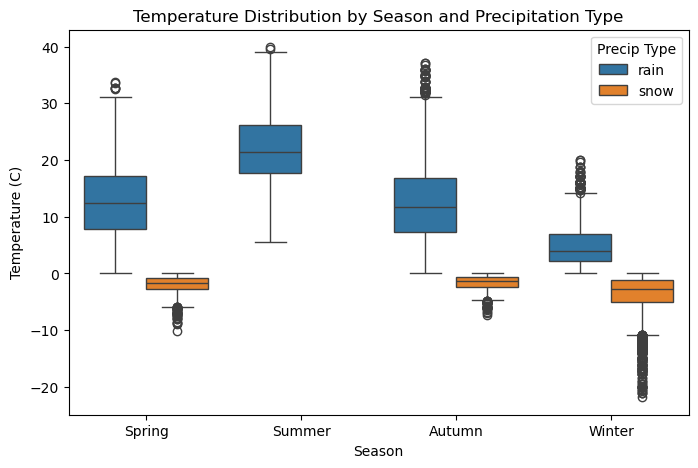

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Season',
    y='Temperature (C)',
    hue='Precip Type',
    data=df)
plt.title('Temperature Distribution by Season and Precipitation Type')
plt.show()

Temperature has a strong influence on precipitation type.
- Rain is strongly associated with warmer seasonal conditions, while snowfall occurs almost exclusively during colder temperature ranges. T

## Humidity & Pressure & Visibility

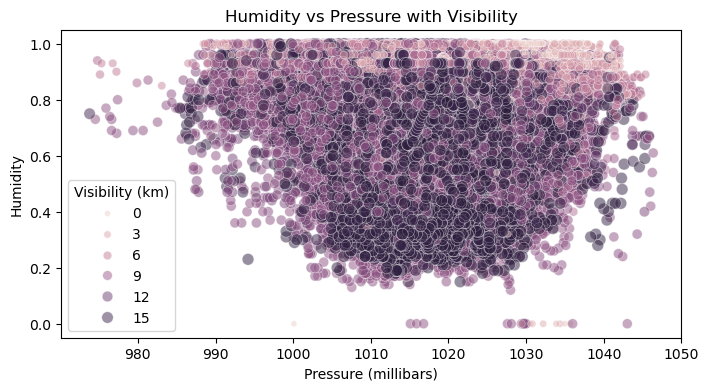

In [60]:
plt.figure(figsize=(8,4))
sns.scatterplot(x='Pressure (millibars)',y='Humidity',size='Visibility (km)',
    hue='Visibility (km)',data=df,
    alpha=0.5)
plt.title('Humidity vs Pressure with Visibility')
plt.show()

- Most observations are concentrated between: 1000–1035 millibars , The atmosphere in this region is mostly stable and moderate, without extreme pressure changes.
- At lower humidity levels, visibility tends to improve.
- More Humidity Usually Means Less Visibility and Foggy Conditions are Connected With High Humidity.

### correlation

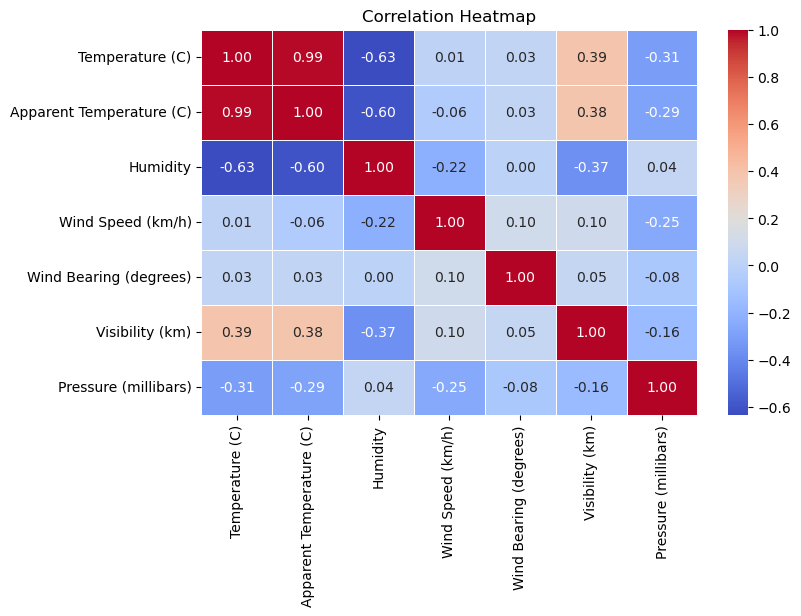

In [54]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap reveals a clear environmental cycle in the dataset. Warmer weather is generally associated with lower humidity, clearer visibility, and slightly lower pressure conditions, while colder weather tends to be more humid, less visible, and linked with higher atmospheric pressure. Humidity plays a central role in controlling visibility and overall weather comfort, while apparent temperature closely follows actual temperature. Overall, the dataset reflects realistic seasonal and atmospheric weather behavior with interconnected climate patterns rather than isolated variables.

# Weather History Dataset — Exploratory Data Analysis Report

## 1. Executive Summary
This dataset captures the historical weather behavior of a UK location through atmospheric variables such as temperature, humidity, pressure, visibility, wind speed, and precipitation patterns. After cleaning missing values, correcting unrealistic pressure anomalies, and removing unreliable features, the dataset revealed highly realistic and interconnected climate behaviors. The analysis shows that the region experiences a predominantly moderate, cloudy, and rainfall-driven climate with strong seasonal weather cycles. Warm weather conditions were generally associated with clearer skies, lower humidity, and better visibility, while colder periods showed higher humidity, reduced visibility, and increased snowfall probability. Overall, the dataset reflects a stable temperate maritime climate with predictable seasonal atmospheric transitions.


## 2. Comprehensive Insights & Patterns
### A. Cloudy and Moderate Climate Dominates
The dataset is mainly dominated by Partly Cloudy, Mostly Cloudy, and Overcast conditions, while extreme weather events are rare. This suggests a stable UK maritime climate with moderate and predictable weather patterns.

### B. Clear Seasonal Temperature Cycle
Temperatures follow a natural yearly cycle: **Summer** (warmest), **Winter** (coldest), and **Spring & Autumn** (transitional seasons). Seasonal changes strongly affect humidity, visibility, and precipitation type.

### C. Rainfall Dominates the Region
Rain dominates most seasons, while snow mainly occurs during winter. This shows that temperature is the main factor controlling precipitation type.

### D. Humidity Reduces Visibility
A strong inverse relationship was observed: **higher humidity → lower visibility** and **lower humidity → clearer atmosphere**. This reflects real-world fog, haze, and mist formation.

### E. Two Major Weather States Emerged
* **Warm Weather State:** Higher temperature, lower humidity, better visibility, and rainfall dominance.
* **Cold Weather State:** Lower temperature, higher humidity, lower visibility, and higher snowfall probability.
* This shows that weather variables behave as an interconnected atmospheric system.

### F. Wind Speeds are Mostly Moderate
Most days experienced calm-to-moderate winds, while strong winds were uncommon. This indicates relatively stable atmospheric conditions.

### G. Pressure Remained Mostly Stable
Pressure showed weak negative relationships with temperature and wind speed. Higher pressure was generally linked with cooler, stable weather, while lower pressure was associated with changing weather conditions.

## 3. Driver Analysis (Factors Affecting the Target Variables)
### A. Temperature — Central Atmospheric Driver
Temperature emerged as the strongest environmental control variable in the dataset.
1. **Humidity → Strong Negative Relationship (r ≈ -0.63):** As temperature increased, humidity consistently decreased. Warm air can hold more moisture before becoming saturated, reducing relative humidity levels. This means warmer conditions tend to produce drier air, a clearer atmosphere, and less fog formation.
2. **Visibility → Moderate Positive Relationship (r ≈ 0.39):** Higher temperatures were associated with improved visibility. Warmer conditions reduce condensation and fog formation, increasing atmospheric clarity. Thus, warm weather generally produced clearer skies, better visibility, and lower atmospheric moisture concentration.
3. **Pressure → Weak-to-Moderate Negative Relationship (r ≈ -0.31):** Higher temperatures tended to occur during relatively lower-pressure conditions. Lower-pressure systems often accompany changing air masses and dynamic atmospheric conditions.

### B. Humidity — Primary Moisture Controller
Humidity strongly influenced atmospheric clarity and weather comfort.
1. **Visibility → Moderate Negative Relationship (r ≈ -0.37):** Higher humidity significantly reduced visibility. Suspended moisture particles create fog, haze, mist, and cloudiness, which scatter light and reduce visual clarity.
2. **Wind Speed → Weak Negative Relationship (r ≈ -0.23):** Increasing wind speed slightly reduced humidity. Moving air disperses moisture concentration and increases evaporation rates.

### C. Precipitation Type — Temperature-Driven Seasonal Variable
Precipitation type displayed a strong non-linear seasonal relationship with temperature.
* **Temperature → Rain vs Snow Transition:** Lower temperatures lead to snowfall, while higher temperatures lead to rainfall. Atmospheric temperature determines whether precipitation remains frozen or melts before reaching the ground. This confirms temperature acts as the dominant physical driver controlling precipitation type.

## 4. Final Conclusions & Synthesis
The EDA shows that this UK region follows a stable and seasonally structured temperate climate. Temperature emerged as the main atmospheric driver, strongly influencing humidity, visibility, precipitation type, and pressure. The region is mostly cloudy and rainfall-dominant, while snowfall mainly occurs during colder seasons.
One of the strongest findings is the emergence of two recurring atmospheric systems: **warm, dry, and clear weather states** and **cold, humid, and fog-prone weather states**.
Humidity strongly affects visibility, while pressure supports overall weather stability. Overall, the dataset reflects predictable seasonal weather behavior with relatively few extreme weather events.


### Top 5 Major Key Findings (Bivariate & Multivariate Analysis)
1. **Temperature and Humidity Showed a Strong Negative Relationship:** As temperature increased, humidity consistently decreased, indicating warmer conditions tend to be drier.
2. **Humidity Strongly Reduced Visibility:** High atmospheric moisture was directly associated with foggy and low-visibility conditions.
3. **Temperature Strongly Controlled Precipitation Type:** Rain dominated warmer conditions, while snow primarily occurred during colder seasonal periods.
4. **Multivariate Analysis Revealed Two Major Weather States:** The dataset consistently formed warm-clear-dry atmospheric conditions and cold-humid-foggy atmospheric conditions.
5. **Visibility Emerged as a Key Indicator of Overall Atmospheric Conditions:** Visibility was strongly influenced by the interaction between humidity, temperature, and pressure, making it one of the most informative environmental variables in the dataset.